In [1]:
import pandas as pd
import numpy as np
 
data = pd.read_csv(r'C:\Users\anast\Downloads\SchizophreniaSymptomnsData.csv')

data.head()

,Name,Age,Gender,Marital_Status,Fatigue,Slowing,Pain,Hygiene,Movement,Schizophrenia
0,Leslie Goodwin,68,Female,Single,0.698075,0.123064,0.375303,0.234639,0.251869,Elevated Proneness
1,Dr. Troy Castaneda,88,Male,Married,0.049245,-0.042080,0.432807,0.501238,0.379948,Moderate Proneness
2,Chelsey Allen,67,Female,Married,0.651995,0.187117,NaN,0.301942,0.302588,Elevated Proneness
3,Dr. Devin Skinner DVM,95,Female,Widowed,0.036324,0.580808,0.005356,0.306968,0.813618,Moderate Proneness
4,Megan Mendez,81,Female,Widowed,0.926727,0.484202,0.702405,0.736054,0.579448,High Proneness


In [2]:
data=data.dropna()

In [3]:
data.nunique()

Name              4201
Age                 41
Gender               2
Marital_Status       4
Fatigue           4318
Slowing           4318
Pain              4318
Hygiene           4318
Movement          4318
Schizophrenia        5
dtype: int64

In [4]:
data.info

<bound method DataFrame.info of                        Name  Age  Gender Marital_Status   Fatigue   Slowing  \
0            Leslie Goodwin   68  Female         Single  0.698075  0.123064   
1        Dr. Troy Castaneda   88    Male        Married  0.049245 -0.042080   
3     Dr. Devin Skinner DVM   95  Female        Widowed  0.036324  0.580808   
4              Megan Mendez   81  Female        Widowed  0.926727  0.484202   
5         Zachary Smith DVM   77    Male        Married  0.145541  0.737656   
...                     ...  ...     ...            ...       ...       ...   
4994          Richard Smith   64    Male        Married  0.045867  0.736874   
4995           Anna Blevins   61  Female         Single  0.933016  0.505532   
4996         Robert Frazier   60  Female         Single  0.260125  0.625811   
4998           Julie Nguyen   76  Female        Widowed  0.265702  0.525682   
4999      Krista Cunningham   59    Male        Married  0.489590  0.630955   

          Pain   Hy

In [5]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OrdinalEncoder

def encode_proneness(df, column_name):
    categories = ['Low Proneness', 'Moderate Proneness', 'Elevated Proneness', 'High Proneness', 'Very High Proneness']

    encoder = OrdinalEncoder(categories=[categories], handle_unknown='use_encoded_value', unknown_value=-1)

    df[column_name] = encoder.fit_transform(df[[column_name]])

    return df

df = pd.DataFrame(data)

print("Original DataFrame:\n", df)

df = encode_proneness(df, 'Schizophrenia')

print("\nEncoded DataFrame:\n", df)

Original DataFrame:
                        Name  Age  Gender Marital_Status   Fatigue   Slowing  \
0            Leslie Goodwin   68  Female         Single  0.698075  0.123064   
1        Dr. Troy Castaneda   88    Male        Married  0.049245 -0.042080   
3     Dr. Devin Skinner DVM   95  Female        Widowed  0.036324  0.580808   
4              Megan Mendez   81  Female        Widowed  0.926727  0.484202   
5         Zachary Smith DVM   77    Male        Married  0.145541  0.737656   
...                     ...  ...     ...            ...       ...       ...   
4994          Richard Smith   64    Male        Married  0.045867  0.736874   
4995           Anna Blevins   61  Female         Single  0.933016  0.505532   
4996         Robert Frazier   60  Female         Single  0.260125  0.625811   
4998           Julie Nguyen   76  Female        Widowed  0.265702  0.525682   
4999      Krista Cunningham   59    Male        Married  0.489590  0.630955   

          Pain   Hygiene  Move

In [6]:
data['Gender']=data['Gender']=='Male'
data['w']=data['Marital_Status']=='Widowed'
data['fm']=data['Marital_Status']=='Divorced'
data['Marital_Status']=data['Marital_Status']=='Married'
data.describe()

,Age,Fatigue,Slowing,Pain,Hygiene,Movement,Schizophrenia
count,4318.000000,4318.000000,4318.000000,4318.000000,4318.000000,4318.000000,4318.000000
mean,74.779064,0.503396,0.499663,0.500529,0.501483,0.503044,2.003242
std,9.561927,0.296260,0.294848,0.294170,0.294218,0.288767,0.647862
min,55.000000,-0.092667,-0.094843,-0.095771,-0.094284,-0.089272,0.000000
25%,67.000000,0.246073,0.249073,0.253225,0.252167,0.259898,2.000000
50%,75.000000,0.507387,0.500709,0.498417,0.503413,0.507957,2.000000
75%,83.000000,0.758491,0.744854,0.749884,0.751913,0.743620,2.000000
max,95.000000,1.091136,1.092146,1.090027,1.086922,1.077088,4.000000


##**Predicting types of schizophrenia**

In [7]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC  
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score  
from sklearn.preprocessing import StandardScaler  

def perform_svm_classification(df, target_column, feature_columns, kernel='linear', C=1.0, gamma='scale', test_size=0.2, random_state=42):
    X = df[feature_columns]  
    y = df[target_column]  
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=random_state)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)  
    X_test_scaled = scaler.transform(X_test)       

   
    model = SVC(kernel=kernel, C=C, gamma=gamma, probability=True, random_state=random_state) # probability=True is required for ROC AUC
    model.fit(X_train_scaled, y_train) 
    
    y_pred = model.predict(X_test_scaled) 
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0) 
    recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    
    roc_auc = roc_auc_score(y_test, model.predict_proba(X_test_scaled), multi_class='ovr')
    
    metrics = {'Accuracy': accuracy, 'Precision': precision, 'Recall': recall, 'F1-score': f1, 'ROC AUC': roc_auc}

    predictions_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})

    coefficients_dict = None
    if kernel == 'linear':
        if hasattr(model, 'coef_') and hasattr(model, 'intercept_'):  
            coefficients = model.coef_
            intercept = model.intercept_
            coefficients_dict = {feature: coef for feature, coef in zip(feature_columns, coefficients[0])}
            coefficients_dict['Intercept'] = intercept[0]
        else:
            print("Warning: Coefficients and intercept not available for the chosen kernel (not linear).")


    return model, predictions_df, metrics, coefficients_dict

In [8]:
target_column = 'Schizophrenia'
feature_columns = ['Age','Gender','Marital_Status','Fatigue','Slowing','Pain','Hygiene','Movement','fm','w']

model, predictions_df, metrics, coefficients_dict = perform_svm_classification(data, target_column, feature_columns, kernel='linear')

print("SVM Model:", model)
print("\nPredictions:")
print(predictions_df)
print("\nEvaluation Metrics:")
print(metrics)
print("\nCoefficients (for linear kernel):")
print(coefficients_dict)

SVM Model: SVC(kernel='linear', probability=True, random_state=42)

Predictions:
      Actual  Predicted
366      2.0        2.0
4299     2.0        2.0
844      2.0        2.0
179      2.0        2.0
123      1.0        1.0
...      ...        ...
4769     0.0        0.0
4753     2.0        2.0
586      2.0        2.0
2211     2.0        2.0
1890     1.0        1.0

[864 rows x 2 columns]

Evaluation Metrics:
{'Accuracy': 0.9872685185185185, 'Precision': 0.9863760809649351, 'Recall': 0.9872685185185185, 'F1-score': 0.9867594960939402, 'ROC AUC': 0.9997990295583508}

Coefficients (for linear kernel):
{'Age': -0.11095300787653084, 'Gender': -0.1430669500094739, 'Marital_Status': -0.3022311261247008, 'Fatigue': -2.954381542512465, 'Slowing': -1.4920650959046675, 'Pain': -1.1086380829323215, 'Hygiene': -1.877818261787084, 'Movement': -2.4607683644370404, 'fm': 0.13317977744515153, 'w': 0.02195486796806989, 'Intercept': -10.546560966039989}



Best Model Results:
Best Hyperparameters: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 1000}
MSE: 0.09
R-squared: 0.78

Feature Importance:
          Feature  Importance
3         Fatigue    0.387389
7        Movement    0.260355
6         Hygiene    0.180013
4         Slowing    0.103354
5            Pain    0.062221
0             Age    0.004801
8              fm    0.000660
1          Gender    0.000502
2  Marital_Status    0.000389
9               w    0.000315


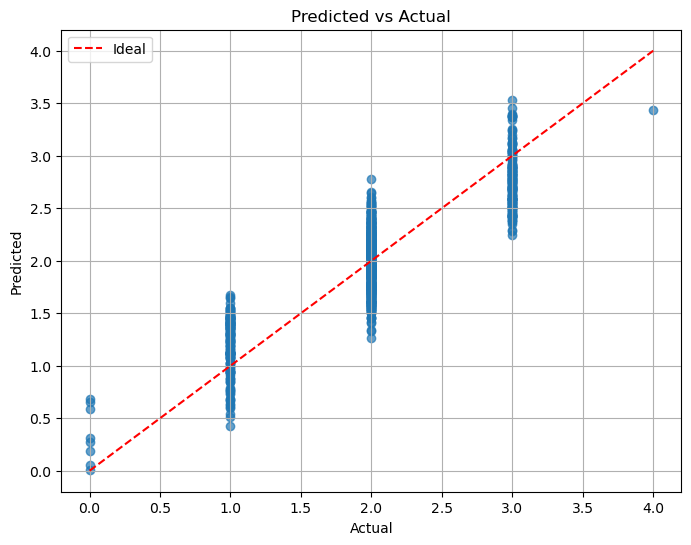

In [9]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

X_cols = ['Age','Gender','Marital_Status','Fatigue','Slowing','Pain','Hygiene','Movement','fm','w']
X = df[X_cols]
y = df['Schizophrenia']


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)  

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

param_grid = {
    'n_estimators': [1000, 2000],
    'learning_rate': [0.05, 0.5],
    'max_depth': [3, 40],
}

gbr = GradientBoostingRegressor(random_state=42)
grid_search = GridSearchCV(gbr, param_grid, scoring='neg_mean_squared_error', cv=2, n_jobs=-1)  
grid_search.fit(X_train, y_train)

best_gbr = grid_search.best_estimator_

predictions = best_gbr.predict(X_test)

mse = mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)
print(f"\nBest Model Results:")
print(f"Best Hyperparameters: {grid_search.best_params_}")
print(f"MSE: {mse:.2f}")
print(f"R-squared: {r2:.2f}")

feature_importance = best_gbr.feature_importances_
feature_importance_df = pd.DataFrame({'Feature': X_cols, 'Importance': feature_importance})
feature_importance_df = feature_importance_df.sort_values('Importance', ascending=False)
print("\nFeature Importance:")
print(feature_importance_df)

plt.figure(figsize=(8, 6))
plt.scatter(y_test, predictions, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--', color='red', label='Ideal')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Predicted vs Actual")
plt.legend()
plt.grid(True)
plt.show()

In [10]:
d0=data[data['Schizophrenia']==0]
d1=data[data['Schizophrenia']==1]
d2=data[data['Schizophrenia']==2]
d3=data[data['Schizophrenia']==3]
d4=data[data['Schizophrenia']==4]

In [11]:
d0.describe()

,Age,Fatigue,Slowing,Pain,Hygiene,Movement,Schizophrenia
count,36.000000,36.000000,36.000000,36.000000,36.000000,36.000000,36.0
mean,74.055556,0.098562,0.225485,0.329219,0.158676,0.134881,0.0
std,9.102416,0.116843,0.249299,0.246778,0.141251,0.128833,0.0
min,55.000000,-0.092667,-0.094441,-0.031819,-0.072947,-0.086526,0.0
25%,67.750000,0.045153,0.056523,0.161980,0.045039,0.037075,0.0
50%,72.500000,0.092584,0.156251,0.336260,0.173176,0.126802,0.0
75%,82.000000,0.143960,0.355930,0.471968,0.248787,0.205197,0.0
max,90.000000,0.511090,1.078955,0.957815,0.496347,0.387344,0.0


In [12]:
d1.describe()

,Age,Fatigue,Slowing,Pain,Hygiene,Movement,Schizophrenia
count,779.000000,779.000000,779.000000,779.000000,779.000000,779.000000,779.0
mean,75.100128,0.236541,0.380144,0.420374,0.322047,0.292643,1.0
std,9.819462,0.194064,0.285786,0.302189,0.252558,0.230278,0.0
min,55.000000,-0.074370,-0.077508,-0.078028,-0.084350,-0.080748,1.0
25%,67.000000,0.088926,0.142271,0.166143,0.111258,0.116862,1.0
50%,75.000000,0.196154,0.329169,0.375004,0.276368,0.245681,1.0
75%,83.000000,0.355203,0.594516,0.674524,0.500829,0.438972,1.0
max,95.000000,0.916359,1.092146,1.090027,1.012412,1.048339,1.0


In [13]:
d2.describe()

,Age,Fatigue,Slowing,Pain,Hygiene,Movement,Schizophrenia
count,2650.000000,2650.000000,2650.000000,2650.000000,2650.000000,2650.000000,2650.0
mean,74.725283,0.500540,0.495533,0.495047,0.504982,0.501395,2.0
std,9.530029,0.270350,0.286567,0.287238,0.283265,0.273498,0.0
min,55.000000,-0.091327,-0.094843,-0.095771,-0.094284,-0.089272,2.0
25%,67.000000,0.287172,0.254438,0.254294,0.272973,0.280765,2.0
50%,75.000000,0.502491,0.492552,0.493804,0.507484,0.507471,2.0
75%,83.000000,0.718653,0.730461,0.740704,0.731742,0.720020,2.0
max,95.000000,1.075474,1.091326,1.084462,1.086922,1.077088,2.0


In [14]:
d3.describe()

,Age,Fatigue,Slowing,Pain,Hygiene,Movement,Schizophrenia
count,841.000000,841.000000,841.000000,841.000000,841.000000,841.000000,841.0
mean,74.708680,0.770757,0.630446,0.595513,0.666076,0.712540,3.0
std,9.461301,0.194338,0.272196,0.282305,0.260276,0.221665,0.0
min,55.000000,0.044980,-0.048601,-0.035846,-0.066721,-0.010386,3.0
25%,67.000000,0.664748,0.433035,0.381539,0.474728,0.563571,3.0
50%,75.000000,0.811120,0.682832,0.629615,0.729274,0.746713,3.0
75%,83.000000,0.911803,0.854333,0.834812,0.874606,0.886905,3.0
max,95.000000,1.091136,1.092069,1.078463,1.081192,1.071814,3.0


In [15]:
d4.describe()

,Age,Fatigue,Slowing,Pain,Hygiene,Movement,Schizophrenia
count,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.0
mean,72.916667,0.934469,0.827350,0.771541,0.870363,0.947800,4.0
std,8.826183,0.064603,0.152663,0.161064,0.119167,0.076968,0.0
min,55.000000,0.828512,0.578284,0.469081,0.650078,0.785813,4.0
25%,69.000000,0.901057,0.739113,0.662161,0.806241,0.907437,4.0
50%,75.000000,0.928752,0.828050,0.762962,0.882747,0.968735,4.0
75%,78.000000,0.995663,0.927098,0.885708,0.921713,1.004473,4.0
max,87.000000,1.014346,1.071390,1.029294,1.058316,1.039342,4.0


##**Clusterization**

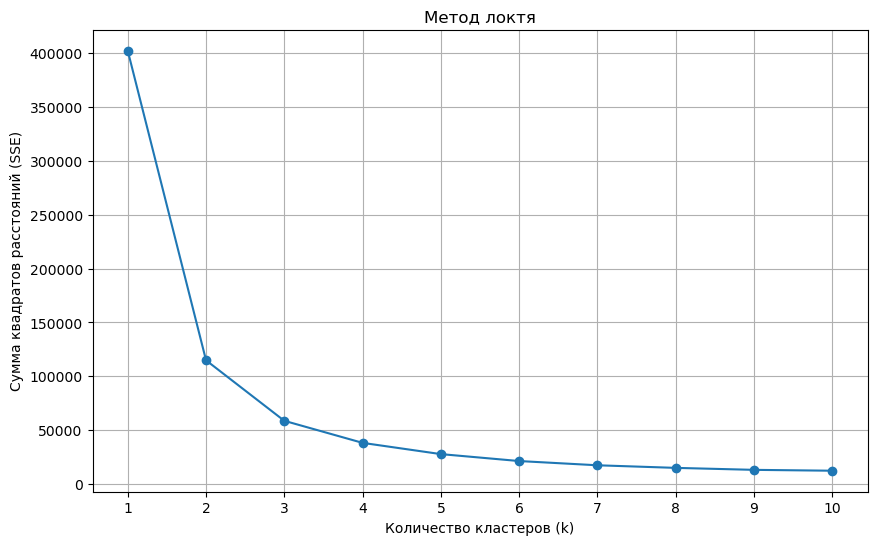

In [17]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
sse = []
data=data.drop('Name',axis=1)

k_values = range(1, 11)
for k in k_values:
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(data)
    sse.append(kmeans.inertia_)  
    
plt.figure(figsize=(10, 6))
plt.plot(k_values, sse, marker='o')
plt.title('Метод локтя')
plt.xlabel('Количество кластеров (k)')
plt.ylabel('Сумма квадратов расстояний (SSE)')
plt.xticks(k_values)
plt.grid()
plt.show()

In [20]:
import numpy as np
from scipy.spatial.distance import cdist
from sklearn.metrics import calinski_harabasz_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

def perform_agglomerative_clustering(df, n_clusters=2, linkage='ward', affinity='euclidean', scale_data=True, tsne_components=2, random_state=42):
    X = df.values  
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    X_scaled = X

    agglomerative = AgglomerativeClustering(n_clusters=n_clusters, linkage=linkage, affinity=affinity)
    cluster_labels = agglomerative.fit_predict(X_scaled)
    
    ch_score = None  
    if len(set(cluster_labels)) > 1 and len(set(cluster_labels)) < len(X_scaled):  
            ch_score = calinski_harabasz_score(X_scaled, cluster_labels)
            print(f"Calinski-Harabasz Score: {ch_score:.3f}")

    df['Cluster'] = cluster_labels

    tsne = TSNE(n_components=tsne_components, random_state=random_state, init='random', learning_rate='auto')
    X_tsne = tsne.fit_transform(X_scaled)
    
    plt.figure(figsize=(8, 6))
    unique_labels = set(cluster_labels)
    n_clusters_ = len(unique_labels)
    colors = plt.cm.viridis(np.linspace(0, 1, len(unique_labels)))

    for k, col in zip(unique_labels, colors):  
        class_member_mask = (cluster_labels == k)
        xy = X_tsne[class_member_mask]
        plt.scatter(xy[:, 0], xy[:, 1], color=col, label=f'Cluster {k}', alpha=0.7)  
    plt.title(f'Agglomerative Clustering with t-SNE (Clusters: {n_clusters_})')
    plt.xlabel('t-SNE Component 1')
    plt.ylabel('t-SNE Component 2')
    plt.legend()  
    plt.grid(True)
    plt.show()

    return agglomerative, df, ch_score

Calinski-Harabasz Score: 11921.899


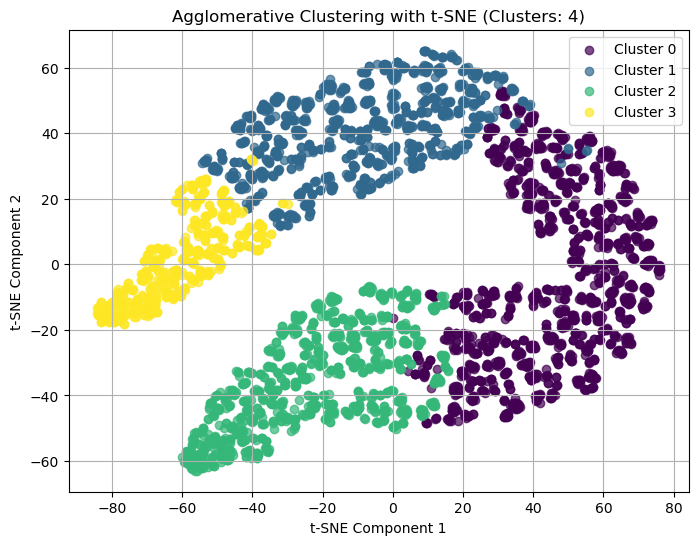


DataFrame with Cluster Labels:

Calinski-Harabasz Score: 11921.899


In [21]:
agglomerative_model, df_with_clusters, calinski_harabasz_score_result = perform_agglomerative_clustering(data, n_clusters=4)
print("\nDataFrame with Cluster Labels:")
print(f"\nCalinski-Harabasz Score: {calinski_harabasz_score_result:.3f}")

In [22]:
d0=data[data['Cluster']==0]
d0.describe()

,Age,Fatigue,Slowing,Pain,Hygiene,Movement,Schizophrenia,Cluster
count,1546.000000,1546.000000,1546.000000,1546.000000,1546.000000,1546.000000,1546.000000,1546.0
mean,72.598318,0.510195,0.490242,0.501785,0.499702,0.501321,1.996766,0.0
std,3.274058,0.298882,0.301024,0.295596,0.294370,0.288438,0.654080,0.0
min,66.000000,-0.084985,-0.094843,-0.088660,-0.084350,-0.089272,0.000000,0.0
25%,70.000000,0.249960,0.229936,0.253611,0.250132,0.253110,2.000000,0.0
50%,73.000000,0.518435,0.489327,0.504320,0.496951,0.505370,2.000000,0.0
75%,76.000000,0.764432,0.745008,0.749498,0.752090,0.739377,2.000000,0.0
max,78.000000,1.086314,1.078955,1.088657,1.081192,1.071814,4.000000,0.0


In [23]:
d1=data[data['Cluster']==1]
d1.describe()

,Age,Fatigue,Slowing,Pain,Hygiene,Movement,Schizophrenia,Cluster
count,1120.000000,1120.000000,1120.000000,1120.000000,1120.000000,1120.000000,1120.000000,1120.0
mean,82.404464,0.503448,0.507963,0.500940,0.511406,0.516797,2.039286,1.0
std,2.407127,0.298151,0.284780,0.292306,0.290458,0.287801,0.655131,0.0
min,77.000000,-0.091327,-0.094441,-0.095771,-0.084083,-0.080449,0.000000,1.0
25%,80.000000,0.243528,0.271607,0.253139,0.268233,0.271227,2.000000,1.0
50%,82.000000,0.500975,0.504026,0.502053,0.518903,0.520077,2.000000,1.0
75%,84.000000,0.759132,0.741728,0.746264,0.764503,0.759514,2.000000,1.0
max,87.000000,1.091136,1.092069,1.074333,1.086922,1.073987,4.000000,1.0


In [24]:
d2=data[data['Cluster']==2]
d2.describe()

,Age,Fatigue,Slowing,Pain,Hygiene,Movement,Schizophrenia,Cluster
count,1097.000000,1097.000000,1097.000000,1097.000000,1097.000000,1097.000000,1097.000000,1097.0
mean,62.556974,0.493835,0.502346,0.492607,0.497044,0.508994,1.991796,2.0
std,3.020715,0.288537,0.292174,0.297665,0.295157,0.286747,0.625585,0.0
min,55.000000,-0.079939,-0.087798,-0.087819,-0.094284,-0.066161,0.000000,2.0
25%,60.000000,0.247594,0.249197,0.241350,0.240452,0.277317,2.000000,2.0
50%,63.000000,0.499759,0.507102,0.486407,0.500297,0.511315,2.000000,2.0
75%,65.000000,0.744803,0.738599,0.749739,0.747003,0.748213,2.000000,2.0
max,67.000000,1.079193,1.091326,1.090027,1.077783,1.073214,4.000000,2.0


In [25]:
d3=data[data['Cluster']==3]
d3.describe()

,Age,Fatigue,Slowing,Pain,Hygiene,Movement,Schizophrenia,Cluster
count,555.000000,555.000000,555.000000,555.000000,555.000000,555.000000,555.000000,555.0
mean,89.623423,0.503249,0.503853,0.511855,0.495192,0.468325,1.971171,3.0
std,2.333362,0.300413,0.302686,0.287256,0.299743,0.293472,0.657556,0.0
min,86.000000,-0.092667,-0.076232,-0.047719,-0.055997,-0.086526,0.000000,3.0
25%,88.000000,0.246321,0.246862,0.271574,0.234899,0.213807,2.000000,3.0
50%,89.000000,0.501683,0.495124,0.507236,0.501208,0.474899,2.000000,3.0
75%,91.000000,0.760233,0.765157,0.761427,0.747599,0.700481,2.000000,3.0
max,95.000000,1.075474,1.092146,1.084116,1.047324,1.077088,4.000000,3.0


In [27]:
target_column = 'Cluster'
feature_columns = ['Age','Gender','Marital_Status','Fatigue','Slowing','Pain','Hygiene','Movement','fm','w','Schizophrenia']

model, predictions_df, metrics, coefficients_dict = perform_svm_classification(data, target_column, feature_columns, kernel='linear')

print("SVM Model:", model)
print("\nPredictions:")
print(predictions_df)
print("\nEvaluation Metrics:")
print(metrics)
print("\nCoefficients (for linear kernel):")
print(coefficients_dict)

SVM Model: SVC(kernel='linear', probability=True, random_state=42)

Predictions:
      Actual  Predicted
366        1          1
4299       0          0
844        0          0
179        1          1
123        1          1
...      ...        ...
4769       1          0
4753       0          0
586        2          2
2211       0          1
1890       0          0

[864 rows x 2 columns]

Evaluation Metrics:
{'Accuracy': 0.9652777777777778, 'Precision': 0.9657742114559918, 'Recall': 0.9652777777777778, 'F1-score': 0.9652803566610614, 'ROC AUC': 0.9988555976501945}

Coefficients (for linear kernel):
{'Age': -9.868310235700235, 'Gender': 0.07399495955144175, 'Marital_Status': -0.012905798305424376, 'Fatigue': 0.0763694179642389, 'Slowing': -0.058774908781575874, 'Pain': 0.08320323235518545, 'Hygiene': 0.03489923731068334, 'Movement': -0.11190701799245328, 'fm': -0.11665532670939793, 'w': 0.03337142647901681, 'Schizophrenia': -0.41398022066034246, 'Intercept': 3.6137308123245964}



Best Model Results:
Best Hyperparameters: {'learning_rate': 0.05, 'max_depth': 40, 'n_estimators': 1000}
MSE: 0.04
R-squared: 0.97

Feature Importance:
           Feature  Importance
0              Age    0.956446
10   Schizophrenia    0.022562
2   Marital_Status    0.005744
6          Hygiene    0.004510
1           Gender    0.004146
3          Fatigue    0.003869
5             Pain    0.001486
8               fm    0.000509
7         Movement    0.000459
4          Slowing    0.000257
9                w    0.000011


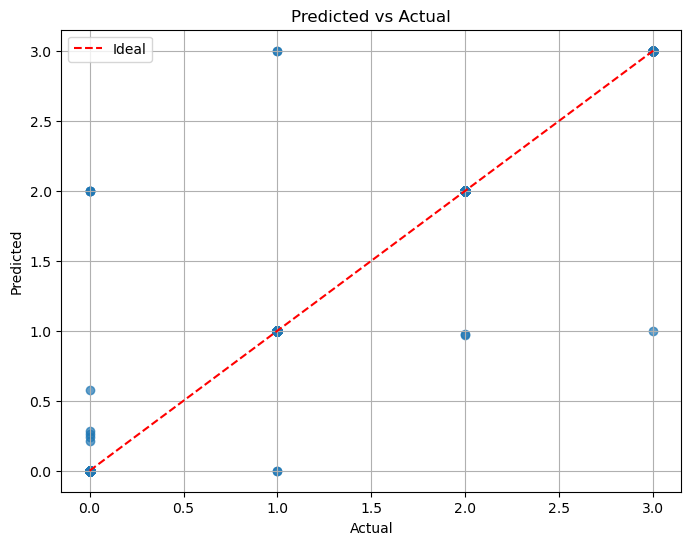

In [29]:
X_cols = ['Age','Gender','Marital_Status','Fatigue','Slowing','Pain','Hygiene','Movement','fm','w','Schizophrenia']
X = data[X_cols]
y = data['Cluster']


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)  

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

param_grid = {
    'n_estimators': [1000, 2000],
    'learning_rate': [0.05, 0.5],
    'max_depth': [3, 40],
}

gbr = GradientBoostingRegressor(random_state=42)
grid_search = GridSearchCV(gbr, param_grid, scoring='neg_mean_squared_error', cv=2, n_jobs=-1)  
grid_search.fit(X_train, y_train)

best_gbr = grid_search.best_estimator_

predictions = best_gbr.predict(X_test)

mse = mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)
print(f"\nBest Model Results:")
print(f"Best Hyperparameters: {grid_search.best_params_}")
print(f"MSE: {mse:.2f}")
print(f"R-squared: {r2:.2f}")

feature_importance = best_gbr.feature_importances_
feature_importance_df = pd.DataFrame({'Feature': X_cols, 'Importance': feature_importance})
feature_importance_df = feature_importance_df.sort_values('Importance', ascending=False)
print("\nFeature Importance:")
print(feature_importance_df)

plt.figure(figsize=(8, 6))
plt.scatter(y_test, predictions, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--', color='red', label='Ideal')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Predicted vs Actual")
plt.legend()
plt.grid(True)
plt.show()

##**Clusterization without Age**

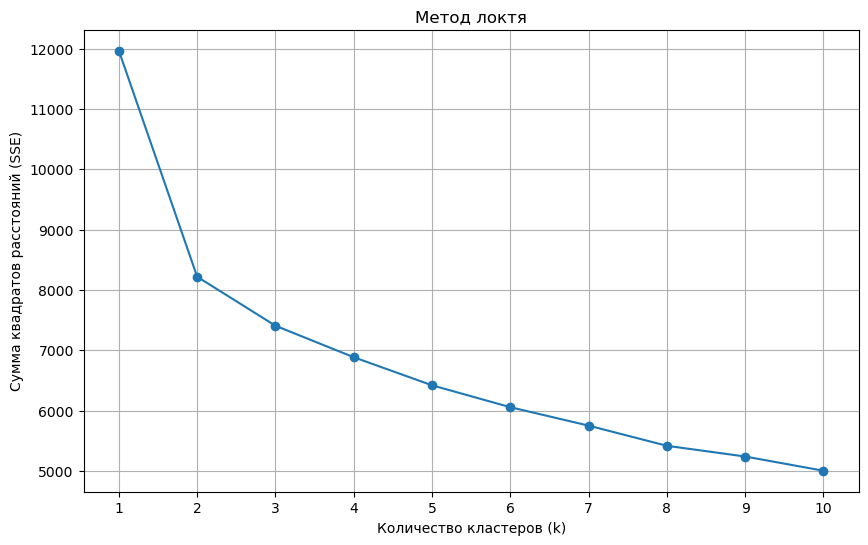

In [31]:
data.drop('Cluster',axis=1)
sse = []

k_values = range(1, 11)
for k in k_values:
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(data)
    sse.append(kmeans.inertia_)  
    
plt.figure(figsize=(10, 6))
plt.plot(k_values, sse, marker='o')
plt.title('Метод локтя')
plt.xlabel('Количество кластеров (k)')
plt.ylabel('Сумма квадратов расстояний (SSE)')
plt.xticks(k_values)
plt.grid()
plt.show()

Calinski-Harabasz Score: 812.138


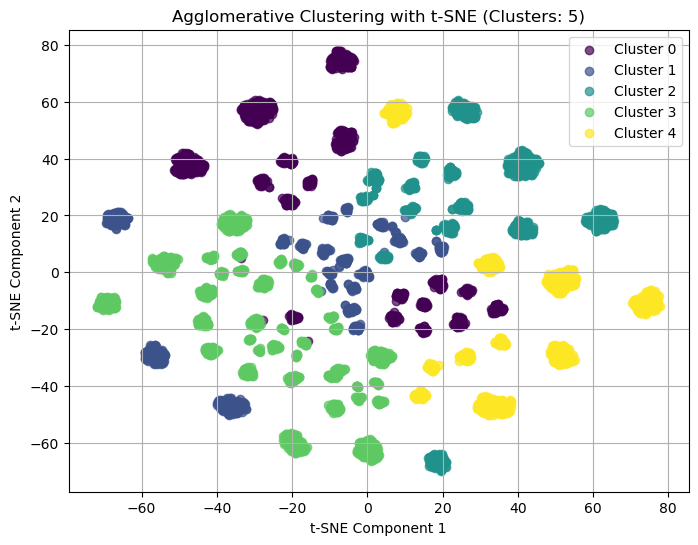


DataFrame with Cluster Labels:

Calinski-Harabasz Score: 812.138


In [33]:
agglomerative_model, df_with_clusters, calinski_harabasz_score_result = perform_agglomerative_clustering(data, n_clusters=5)
print("\nDataFrame with Cluster Labels:")
print(f"\nCalinski-Harabasz Score: {calinski_harabasz_score_result:.3f}")

In [34]:
target_column = 'Cluster'
feature_columns = ['Gender','Marital_Status','Fatigue','Slowing','Pain','Hygiene','Movement','fm','w','Schizophrenia']

model, predictions_df, metrics, coefficients_dict = perform_svm_classification(data, target_column, feature_columns, kernel='linear')

print("SVM Model:", model)
print("\nPredictions:")
print(predictions_df)
print("\nEvaluation Metrics:")
print(metrics)
print("\nCoefficients (for linear kernel):")
print(coefficients_dict)

SVM Model: SVC(kernel='linear', probability=True, random_state=42)

Predictions:
      Actual  Predicted
366        0          0
4299       2          2
844        0          0
179        4          3
123        1          2
...      ...        ...
4769       1          2
4753       2          1
586        1          2
2211       0          0
1890       2          1

[864 rows x 2 columns]

Evaluation Metrics:
{'Accuracy': 0.5659722222222222, 'Precision': 0.5315883559459885, 'Recall': 0.5659722222222222, 'F1-score': 0.5324115761803964, 'ROC AUC': 0.8548835455926804}

Coefficients (for linear kernel):
{'Gender': -6.9478145596421625e-06, 'Marital_Status': -0.43845872303178957, 'Fatigue': 0.00028897314474207736, 'Slowing': 0.000157470452789632, 'Pain': 0.00017446447944495513, 'Hygiene': 0.00015351767983751152, 'Movement': 0.0004040998120276029, 'fm': 0.435393003326205, 'w': 2.220446049250313e-16, 'Schizophrenia': 1.2958030039926343, 'Intercept': 0.021671349715597293}


In [35]:
d0=data[data['Cluster']==0]
d0.describe()

,Fatigue,Slowing,Pain,Hygiene,Movement,Schizophrenia,Cluster
count,859.000000,859.000000,859.000000,859.000000,859.000000,859.000000,859.0
mean,0.644170,0.562276,0.557238,0.580566,0.608143,2.511059,0.0
std,0.273804,0.293193,0.295628,0.283776,0.273294,0.520719,0.0
min,-0.082600,-0.089292,-0.090001,-0.084083,-0.054239,2.000000,0.0
25%,0.444640,0.319001,0.321295,0.355839,0.414664,2.000000,0.0
50%,0.695570,0.597036,0.580303,0.619639,0.640195,3.000000,0.0
75%,0.872935,0.819576,0.822219,0.823685,0.829901,3.000000,0.0
max,1.091136,1.092069,1.074333,1.081192,1.071814,4.000000,0.0


In [36]:
d1=data[data['Cluster']==1]
d1.describe()

,Fatigue,Slowing,Pain,Hygiene,Movement,Schizophrenia,Cluster
count,642.000000,642.000000,642.000000,642.000000,642.000000,642.000000,642.0
mean,0.339430,0.440927,0.443940,0.406720,0.371637,1.383178,1.0
std,0.254548,0.294050,0.293612,0.283793,0.267878,0.549767,0.0
min,-0.079939,-0.094441,-0.087819,-0.084074,-0.086526,0.000000,1.0
25%,0.136509,0.193059,0.193256,0.164610,0.153006,1.000000,1.0
50%,0.286792,0.434210,0.415559,0.376988,0.323921,1.000000,1.0
75%,0.533765,0.670693,0.687386,0.634297,0.557781,2.000000,1.0
max,1.034454,1.092146,1.090027,1.086922,1.048339,2.000000,1.0


In [37]:
d2=data[data['Cluster']==2]
d2.describe()

,Fatigue,Slowing,Pain,Hygiene,Movement,Schizophrenia,Cluster
count,844.000000,844.000000,844.000000,844.000000,844.000000,844.000000,844.0
mean,0.392498,0.449366,0.458028,0.423761,0.414857,1.566351,2.0
std,0.273331,0.287265,0.291055,0.282386,0.274414,0.528303,0.0
min,-0.091327,-0.076242,-0.088660,-0.084350,-0.089272,0.000000,2.0
25%,0.156035,0.197384,0.210252,0.181497,0.179512,1.000000,2.0
50%,0.355505,0.438679,0.449215,0.395894,0.383739,2.000000,2.0
75%,0.593696,0.692742,0.691581,0.639173,0.629161,2.000000,2.0
max,1.063432,1.078955,1.088657,1.048066,1.068545,2.000000,2.0


In [38]:
d3=data[data['Cluster']==3]
d3.describe()

,Fatigue,Slowing,Pain,Hygiene,Movement,Schizophrenia,Cluster
count,1203.000000,1203.000000,1203.000000,1203.000000,1203.000000,1203.000000,1203.0
mean,0.540936,0.514128,0.519665,0.519404,0.526810,2.153782,3.0
std,0.284904,0.293497,0.292703,0.294200,0.286262,0.530713,0.0
min,-0.092667,-0.078805,-0.064086,-0.094284,-0.075737,0.000000,3.0
25%,0.316914,0.262441,0.271398,0.275890,0.300853,2.000000,3.0
50%,0.559406,0.511459,0.523637,0.524999,0.543482,2.000000,3.0
75%,0.785554,0.758792,0.777916,0.766369,0.759233,2.000000,3.0
max,1.079193,1.071390,1.084462,1.077783,1.077088,4.000000,3.0


In [39]:
d4=data[data['Cluster']==4]
d4.describe()

,Fatigue,Slowing,Pain,Hygiene,Movement,Schizophrenia,Cluster
count,770.000000,770.000000,770.000000,770.000000,770.000000,770.000000,770.0
mean,0.545966,0.511317,0.501132,0.549461,0.554890,2.197403,4.0
std,0.290164,0.290599,0.284291,0.286963,0.274709,0.404775,0.0
min,-0.083447,-0.094843,-0.095771,-0.072673,-0.080449,2.000000,4.0
25%,0.309586,0.274392,0.261696,0.312696,0.345216,2.000000,4.0
50%,0.577941,0.519404,0.510392,0.571735,0.568880,2.000000,4.0
75%,0.789129,0.756838,0.730701,0.799904,0.795500,2.000000,4.0
max,1.084535,1.077720,1.078463,1.083349,1.073987,4.000000,4.0



Best Model Results:
Best Hyperparameters: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 1000}
MSE: 0.96
R-squared: 0.52

Feature Importance:
          Feature  Importance
8               w    0.329280
9   Schizophrenia    0.229842
7              fm    0.114646
2         Fatigue    0.057307
6        Movement    0.053988
1  Marital_Status    0.053952
5         Hygiene    0.053145
3         Slowing    0.051345
4            Pain    0.042104
0          Gender    0.014390


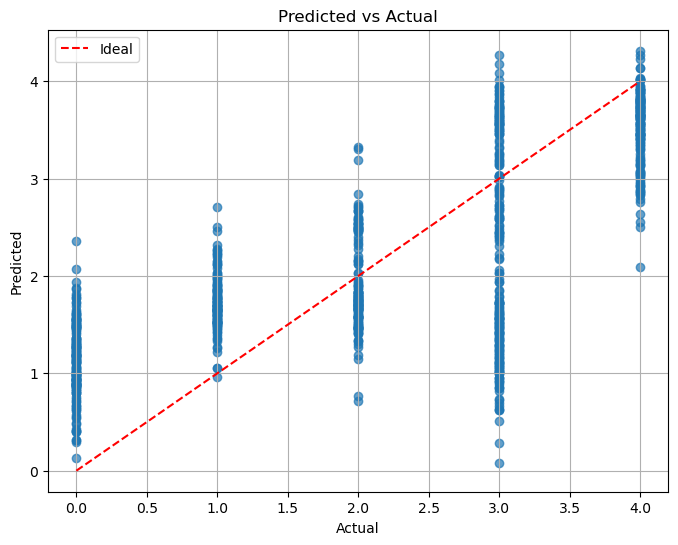

In [40]:
X_cols = ['Gender','Marital_Status','Fatigue','Slowing','Pain','Hygiene','Movement','fm','w','Schizophrenia']
X = data[X_cols]
y = data['Cluster']


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)  

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

param_grid = {
    'n_estimators': [1000, 2000],
    'learning_rate': [0.05, 0.5],
    'max_depth': [3, 40],
}

gbr = GradientBoostingRegressor(random_state=42)
grid_search = GridSearchCV(gbr, param_grid, scoring='neg_mean_squared_error', cv=2, n_jobs=-1)  
grid_search.fit(X_train, y_train)

best_gbr = grid_search.best_estimator_

predictions = best_gbr.predict(X_test)

mse = mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)
print(f"\nBest Model Results:")
print(f"Best Hyperparameters: {grid_search.best_params_}")
print(f"MSE: {mse:.2f}")
print(f"R-squared: {r2:.2f}")

feature_importance = best_gbr.feature_importances_
feature_importance_df = pd.DataFrame({'Feature': X_cols, 'Importance': feature_importance})
feature_importance_df = feature_importance_df.sort_values('Importance', ascending=False)
print("\nFeature Importance:")
print(feature_importance_df)

plt.figure(figsize=(8, 6))
plt.scatter(y_test, predictions, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--', color='red', label='Ideal')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Predicted vs Actual")
plt.legend()
plt.grid(True)
plt.show()